# ΔF/F vs OASIS events — responses aligned to the preferred Gabor

The mesoscope NWB files carry two versions of every ROI's activity:

* **`dff_timeseries` — ΔF/F.** Neuropil-corrected fluorescence relative to a
  running baseline. Continuous and slow: GCaMP rises within a frame but decays
  over roughly half a second to a second.
* **`event_timeseries` — OASIS events.** The same trace deconvolved with
  [aind-ophys-oasis-event-detection](../../aind-ophys-oasis-event-detection)
  (AR(1) model, parameters auto-estimated per ROI). Non-negative and sparse:
  each fluorescence transient is replaced by events on its rising edge, which
  makes it the closer analogue of a spike rate. Rerunning
  `oasis.functions.deconvolve` on the stored ΔF/F reproduces these events to
  float32 precision, so they are not something to recompute.

This notebook picks ROIs that respond strongly to one Gabor patch in the Siegle
RF test (ΔF/F results, 1000 shuffles) and plots both signals aligned to the
onsets of that preferred Gabor.

**Stimulus.** Gabor patches on a 9 × 9 grid (±40°) × 3 orientations, 0.267 s
each, shown back to back without a blank, 5 repeats per (orientation,
position). Imaging runs at ~9.5 Hz, so one Gabor spans about 2.5 frames.

In [1]:
import sys
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

sys.path.append('..')
import utils

## Configuration

In [2]:
SESSION = 'sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys'
NWB_PATH = Path('../../../rawdata/allen_open_scope/meso/sub-832700') / f'{SESSION}.nwb'
GABOR_ROOT = Path('../../../results/allen_open_scope/rf/gabors')
STIM_TABLE = 'RF mapping_presentations'

# ΔF/F results now live in a per-signal tree; runs from before that change sit
# directly under the session directory
SIEGLE_DIR = next(d for d in (GABOR_ROOT / 'dff' / SESSION, GABOR_ROOT / SESSION) if d.is_dir())

N_UNITS = 6            # example ROIs to show
PRE, POST = 1.0, 2.5   # seconds shown before / after the Gabor onset

DFF_COLOR = '#2a78d6'
EVENTS_COLOR = '#eb6834'
REF_COLOR = '0.45'     # mean response to all other Gabors
STIM_COLOR = '0.88'    # Gabor on screen

print(f'Siegle results: {SIEGLE_DIR}')

Siegle results: ../../../results/allen_open_scope/rf/gabors/sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06-12_ophys


In [3]:
stream = utils.open_local(str(NWB_PATH))
df_rf = stream.stim_df(STIM_TABLE)
# the NWB stores these as strings; as text, '-10.0' sorts before '-40.0'
df_rf[['X', 'Y', 'Orientation']] = df_rf[['X', 'Y', 'Orientation']].astype(float)

x_pos = np.sort(df_rf['X'].unique())
y_pos = np.sort(df_rf['Y'].unique())
gabor_dur = np.median(df_rf['stop_time'] - df_rf['start_time'])
print(f'{len(df_rf)} Gabor presentations, {gabor_dur:.3f} s each, '
      f'{len(x_pos)} x {len(y_pos)} positions')

1215 Gabor presentations, 0.267 s each, 9 x 9 positions


## Pick example ROIs

Per ROI, the best orientation is the one with the lowest p-value. Many ROIs sit
on the permutation floor 1/(n_shuffle + 1) in more than one orientation, so ties
go to the larger peak z. The *preferred Gabor* is the grid position with the
peak z in that orientation. The examples are the ROIs at the p-value floor with
the largest peak z.

Selecting on the ΔF/F test is safe here: a continuous trace never produces the
all-tied null that gives silent ROIs a spurious floor p-value, which the sparse
events can.

In [4]:
def load_siegle_results(path):
    """One row per ROI of an optimized Siegle file: best orientation, preferred Gabor, peak z.

    `row` is the ROI's position in the plane's ROI table, i.e. its row in
    stream.dff_df(plane) and stream.events_df(plane).
    """
    with h5py.File(path) as hf:
        plane = hf.attrs['plane']
        n_shuffle = int(hf.attrs['n_shuffle'])
        names = hf['unit_names'][:].astype(str)
        p = hf['p_value'][:]                        # (n_rois, n_ori)
        z = hf['z_score_response'][:]               # (n_rois, n_ori, nx, ny)
        best_delay, best_duration = hf['best_delay'][:], hf['best_duration'][:]
        orientations = hf['orientations'][:]
        xs, ys = hf['x_positions'][:], hf['y_positions'][:]

    n_rois, n_ori, nx, ny = z.shape
    z_peak = z.reshape(n_rois, n_ori, -1).max(axis=2)
    tied = p == p.min(axis=1, keepdims=True)
    o = np.where(tied, z_peak, -np.inf).argmax(axis=1)
    r = np.arange(n_rois)
    xi, yi = np.unravel_index(z[r, o].reshape(n_rois, -1).argmax(axis=1), (nx, ny))

    return pd.DataFrame({
        'plane': plane, 'row': r, 'unit_name': names,
        'p_value': p[r, o], 'z_peak': z_peak[r, o],
        'ori': orientations[o], 'ori_deg': np.rad2deg(orientations[o]),
        'x': xs[xi], 'y': ys[yi],
        'delay': best_delay[r, o], 'duration': best_duration[r, o],
        'z_map': list(z[r, o]),
        'n_shuffle': n_shuffle,
    })


files = sorted(SIEGLE_DIR.glob(f'{SESSION}__rf-dff__*__optimized.h5'))
units = pd.concat([load_siegle_results(f) for f in files], ignore_index=True)

p_floor = 1 / (units['n_shuffle'].iloc[0] + 1)
at_floor = units[np.isclose(units['p_value'], p_floor)]
print(f'{len(units)} ROIs in {len(files)} planes, {len(at_floor)} at the p-value floor ({p_floor:.4f})')

examples = at_floor.nlargest(N_UNITS, 'z_peak').reset_index(drop=True)
examples[['unit_name', 'p_value', 'z_peak', 'ori_deg', 'x', 'y', 'delay', 'duration']]

2458 ROIs in 8 planes, 1416 at the p-value floor (0.0010)


,unit_name,p_value,z_peak,ori_deg,x,y,delay,duration
0,VISp_0_roi26,0.000999,5.711349,0.0,10.0,0.0,0.0,0.50
1,VISl_5_roi377,0.000999,5.022735,0.0,40.0,0.0,0.0,0.25
2,VISp_0_roi1,0.000999,4.956885,90.0,-10.0,-20.0,0.0,0.25
3,VISp_1_roi451,0.000999,4.914995,0.0,-10.0,-10.0,0.0,0.25
4,VISp_1_roi36,0.000999,4.852144,45.0,0.0,-20.0,0.0,0.50
5,VISl_4_roi21,0.000999,4.805296,0.0,-40.0,20.0,0.0,0.50


## Load both signals

Both time series come from the same frames and the same ROI table, so one time
axis and one row index serve both.

In [5]:
traces = {}
for plane in examples['plane'].unique():
    dff, events = stream.dff_df(plane), stream.events_df(plane)
    assert np.array_equal(dff.columns, events.columns)
    traces[plane] = {'times': dff.columns.to_numpy(float),
                     'dff': dff.to_numpy(),
                     'events': events.to_numpy()}

## Cutting out trials

`first[:, None] + k[None, :]` adds a column (one frame index per trial) to a row
(one offset per lag). NumPy **broadcasts** the two into an
(n_trials, n_lags) matrix of frame indices, and `trace[idx]` then gathers every
trial segment in one step. It is the vectorised form of a double loop over
trials and lags, and the same pattern works for any event-aligned analysis.

Lags are counted in imaging frames, not seconds. Imaging and stimulus clocks are
not locked, so frame k after an onset was acquired somewhere in
[k·dt, (k+1)·dt). Trial averages are therefore plotted at the bin centres
(k + ½)·dt, while single trials are plotted at their exact acquisition times.

In [6]:
def peri_stimulus(trace, times, onsets, pre=PRE, post=POST):
    """Segments of `trace` around each onset, one row per trial.

    Returns (segments, rel_times, lags): segments and rel_times are
    (n_trials, n_lags), the values and their exact times relative to the onset;
    lags (n_lags,) is the bin centre of each frame offset.

    Imaging stops ~1.5 s after the last Gabor, so trials whose window runs past
    the last frame are dropped rather than padded.
    """
    dt = np.median(np.diff(times))
    k = np.arange(-int(np.ceil(pre / dt)), int(np.ceil(post / dt)) + 1)
    first = np.searchsorted(times, onsets)      # first frame at or after each onset
    idx = first[:, None] + k[None, :]
    complete = (idx[:, 0] >= 0) & (idx[:, -1] < len(times))
    idx, onsets = idx[complete], onsets[complete]
    return trace[idx], times[idx] - onsets[:, None], (k + 0.5) * dt


def gabor_onsets(unit):
    """Onsets of the unit's preferred Gabor, and of every other presentation."""
    preferred = (np.isclose(df_rf['Orientation'], unit.ori)
                 & np.isclose(df_rf['X'], unit.x)
                 & np.isclose(df_rf['Y'], unit.y))
    return (df_rf.loc[preferred, 'start_time'].to_numpy(),
            df_rf.loc[~preferred, 'start_time'].to_numpy())

## One ROI over the whole Gabor block

The top example across the full RF-mapping block (left) and zoomed on its
strongest preferred-Gabor trial (right). Vertical lines and bands mark the
preferred Gabor. Each ΔF/F transient shows up as a few events on its rising
edge; the slow decay after it is explained by the calcium kernel and produces
no events.

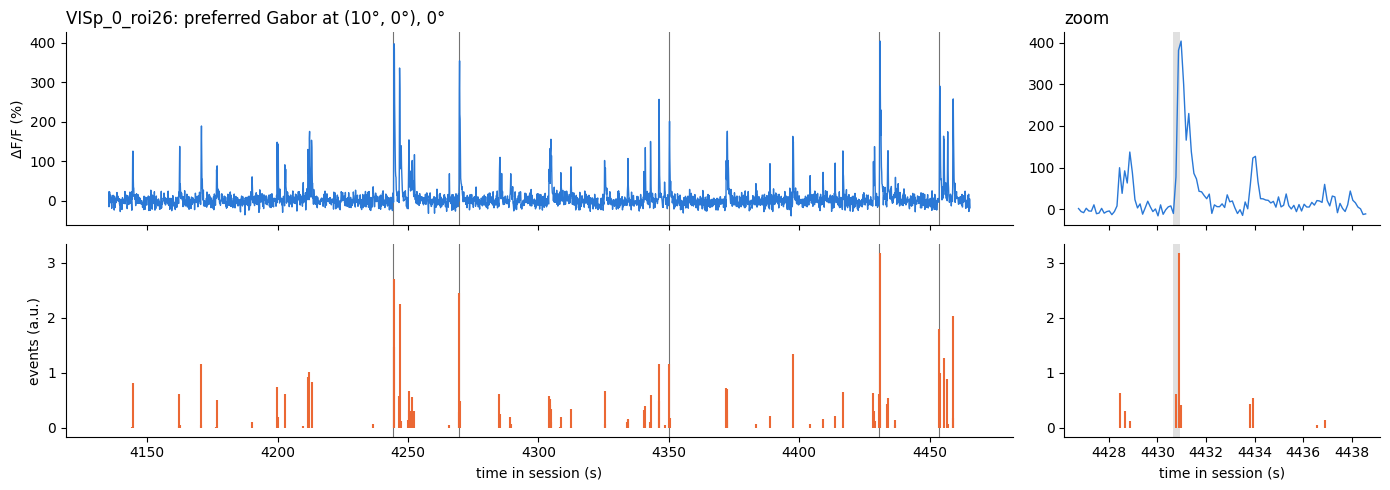

In [7]:
unit = examples.iloc[0]
tr = traces[unit.plane]
t, dff, ev = tr['times'], tr['dff'][unit.row], tr['events'][unit.row]
pref, _ = gabor_onsets(unit)

# zoom on the preferred trial with the largest ΔF/F response in the first second
seg, _, lags = peri_stimulus(dff, t, pref)
best_trial = pref[seg[:, (lags > 0) & (lags < 1)].mean(axis=1).argmax()]

windows = [(df_rf['start_time'].min() - 5, df_rf['stop_time'].max() + 5),
           (best_trial - 4, best_trial + 8)]

fig, axes = plt.subplots(2, 2, figsize=(14, 5), sharex='col',
                         gridspec_kw={'width_ratios': [3, 1]})
for col, (t0, t1) in enumerate(windows):
    m = (t >= t0) & (t <= t1)
    ax_dff, ax_ev = axes[:, col]
    ax_dff.plot(t[m], 100 * dff[m], color=DFF_COLOR, lw=1)
    ax_ev.vlines(t[m], 0, ev[m], color=EVENTS_COLOR, lw=1.5)
    for ax in (ax_dff, ax_ev):
        for onset in pref[(pref >= t0) & (pref <= t1)]:
            if col == 0:
                ax.axvline(onset, color=REF_COLOR, lw=0.8, zorder=0)
            else:
                ax.axvspan(onset, onset + gabor_dur, color=STIM_COLOR, lw=0, zorder=0)
        ax.spines[['top', 'right']].set_visible(False)
    ax_ev.set_xlabel('time in session (s)')

axes[0, 0].set_ylabel('ΔF/F (%)')
axes[1, 0].set_ylabel('events (a.u.)')
axes[0, 0].set_title(f'{unit.unit_name}: preferred Gabor at ({unit.x:.0f}°, {unit.y:.0f}°), '
                     f'{unit.ori_deg:.0f}°', loc='left')
axes[0, 1].set_title('zoom', loc='left')
fig.tight_layout()
plt.show()

## Stimulus-aligned responses, all examples

One row per ROI:

* **left** — Siegle z-map (ΔF/F) at the preferred orientation; the square is the
  preferred Gabor.
* **middle / right** — ΔF/F and events aligned to the 5 onsets of that Gabor.
  Thin lines: single trials. Bold: trial mean. Dashed gray: mean over all other
  Gabor presentations, the level to beat.

Gray band: the Gabor on screen (0 to 0.267 s). Black bar on top: the
(delay, duration) window the Siegle test picked for this ROI. The Gabors run
back to back, so everything before 0 and after 0.267 s is also driven by other
patches — which is exactly what the dashed reference captures.

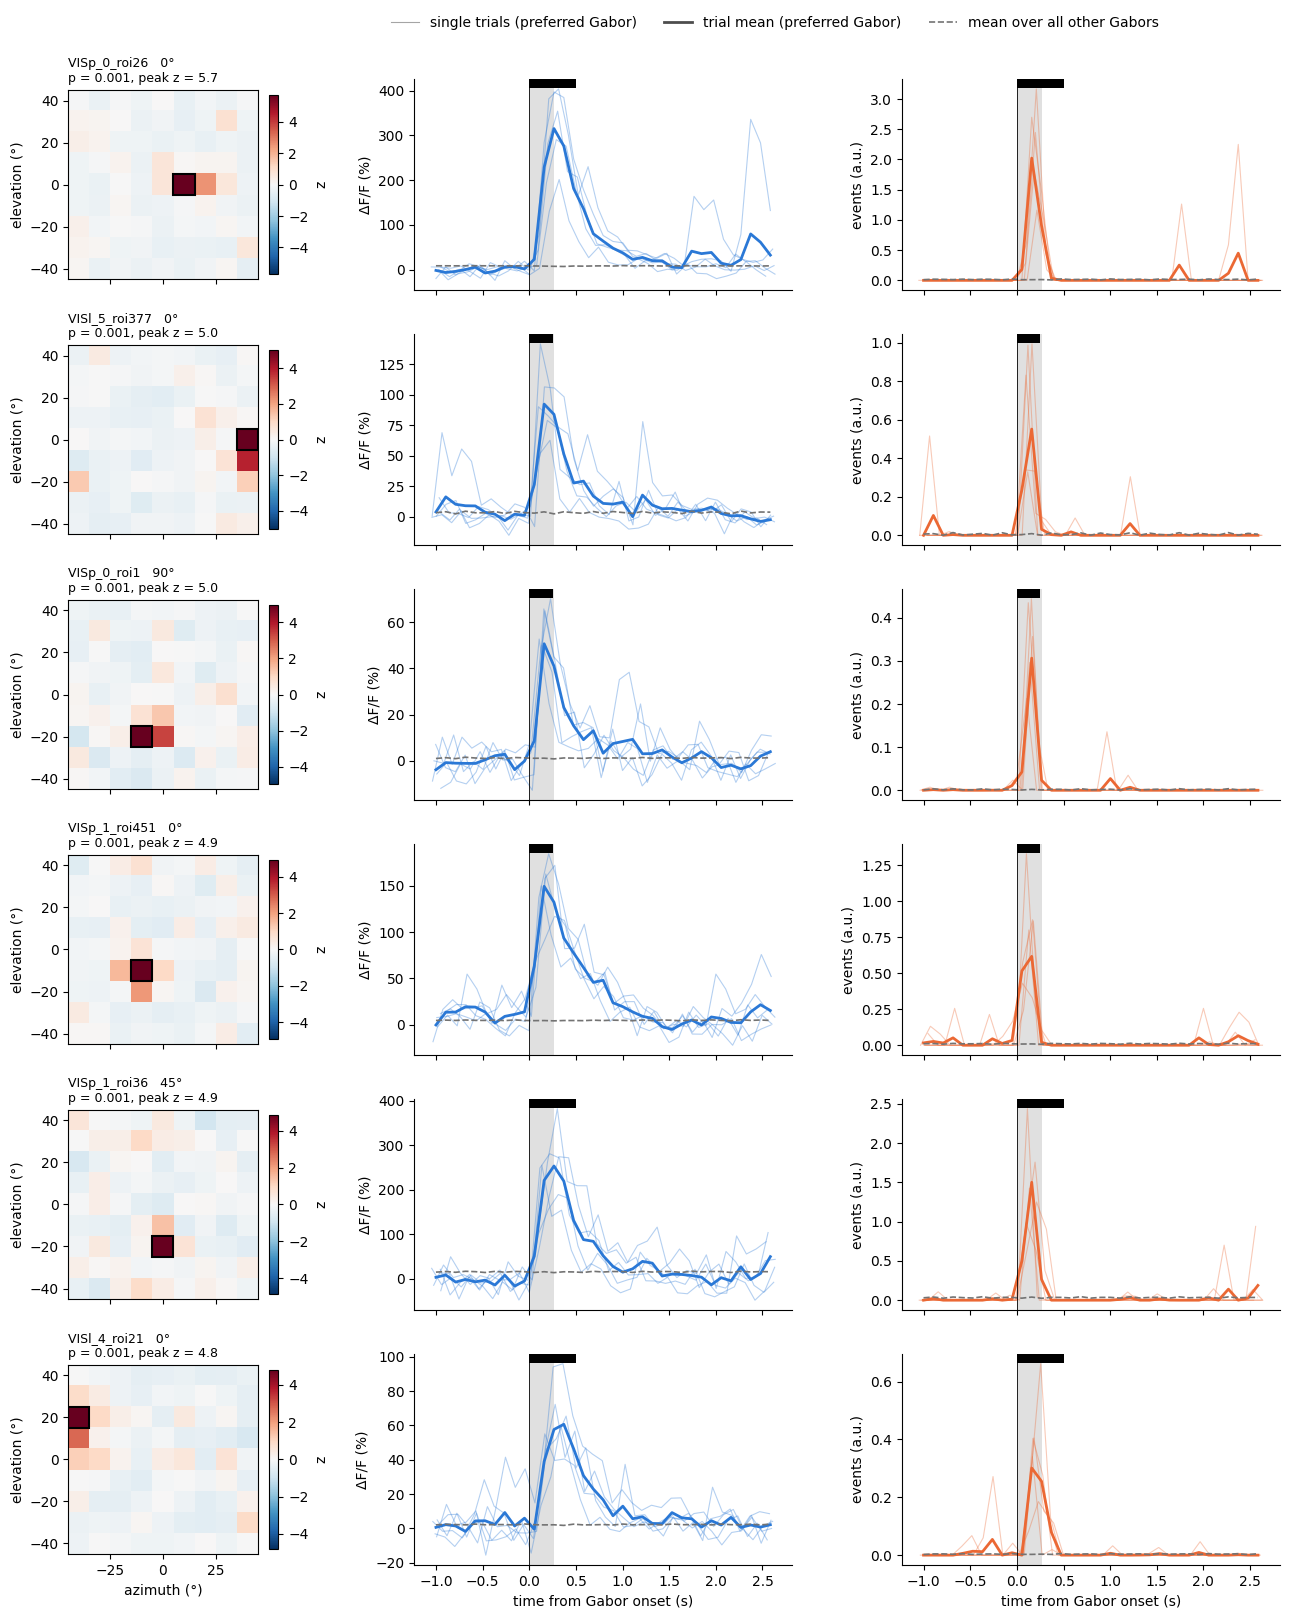

In [11]:
hx, hy = np.diff(x_pos)[0] / 2, np.diff(y_pos)[0] / 2
extent = (x_pos[0] - hx, x_pos[-1] + hx, y_pos[0] - hy, y_pos[-1] + hy)
signals = [('dff', 'ΔF/F (%)', DFF_COLOR, 100), ('events', 'events (a.u.)', EVENTS_COLOR, 1)]

fig, axes = plt.subplots(len(examples), 3, figsize=(13, 2.7 * len(examples)), sharex='col',
                         gridspec_kw={'width_ratios': [1, 1.6, 1.6]})

for (_, unit), row in zip(examples.iterrows(), axes):
    tr = traces[unit.plane]
    pref, other = gabor_onsets(unit)

    ax = row[0]
    vmax = np.abs(unit.z_map).max()
    im = ax.imshow(unit.z_map.T, origin='lower', extent=extent,
                   cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.add_patch(plt.Rectangle((unit.x - hx, unit.y - hy), 2 * hx, 2 * hy,
                               fill=False, ec='k', lw=1.5))
    ax.set_title(f'{unit.unit_name}   {unit.ori_deg:.0f}°\n'
                 f'p = {unit.p_value:.3f}, peak z = {unit.z_peak:.1f}', fontsize=9, loc='left')
    ax.set_ylabel('elevation (°)')
    fig.colorbar(im, ax=ax, shrink=0.85, label='z')

    for ax, (signal, label, color, scale) in zip(row[1:], signals):
        trace = scale * tr[signal][unit.row]
        seg, rel, lags = peri_stimulus(trace, tr['times'], pref)
        ref, _, _ = peri_stimulus(trace, tr['times'], other)

        ax.axvspan(0, gabor_dur, color=STIM_COLOR, lw=0, zorder=0)
        ax.axvspan(unit.delay, unit.delay + unit.duration, ymin=0.96, ymax=1, color='k', lw=0)
        ax.plot(rel.T, seg.T, color=color, lw=0.8, alpha=0.35)
        ax.plot(lags, seg.mean(axis=0), color=color, lw=2)
        ax.plot(lags, ref.mean(axis=0), color=REF_COLOR, lw=1.2, ls='--')
        ax.axvline(0, color='k', lw=0.6)
        ax.set_ylabel(label)
        ax.spines[['top', 'right']].set_visible(False)

axes[-1, 0].set_xlabel('azimuth (°)')
for ax in axes[-1, 1:]:
    ax.set_xlabel('time from Gabor onset (s)')

fig.legend(handles=[Line2D([], [], color='0.3', lw=0.8, alpha=0.5, label='single trials (preferred Gabor)'),
                    Line2D([], [], color='0.3', lw=2, label='trial mean (preferred Gabor)'),
                    Line2D([], [], color=REF_COLOR, lw=1.2, ls='--', label='mean over all other Gabors')],
           loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.6, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()

## Timing across the examples

Trial means, baseline-subtracted (mean over the pre-onset lags) and normalised
to their peak, so both signals share one unitless scale. The table gives the
latency of the peak and the full width at half maximum. Both are quantised to
the ~0.1 s frame interval, so read them as frame counts rather than precise
latencies.

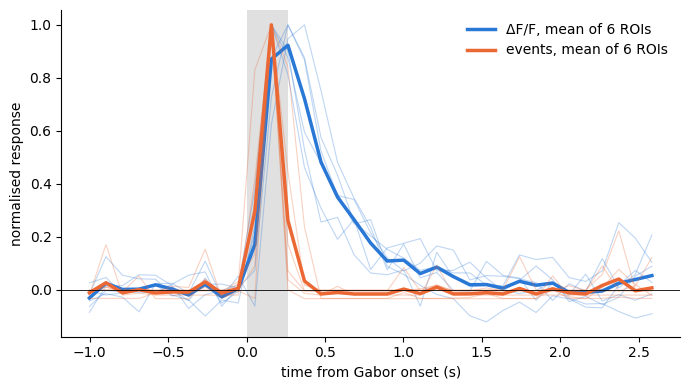

peak_s        fwhm_s       
signal           dff events    dff events
unit_name                                
VISl_4_roi21    0.37   0.16   0.42   0.21
VISl_5_roi377   0.16   0.16   0.32   0.11
VISp_0_roi1     0.16   0.16   0.21   0.11
VISp_0_roi26    0.26   0.16   0.42   0.11
VISp_1_roi36    0.26   0.16   0.42   0.11
VISp_1_roi451   0.16   0.16   0.32   0.21

In [9]:
def normalised_mean(seg, lags):
    m = seg.mean(axis=0)
    m = m - m[lags < 0].mean()
    return m / m.max()


def peak_and_width(m, lags):
    """Latency of the peak, and the width of the contiguous stretch above half of it."""
    i = np.argmax(m)
    above = m >= m[i] / 2
    lo = hi = i
    while lo > 0 and above[lo - 1]:
        lo -= 1
    while hi < len(m) - 1 and above[hi + 1]:
        hi += 1
    return lags[i], (hi - lo + 1) * (lags[1] - lags[0])


fig, ax = plt.subplots(figsize=(7, 4))
ax.axvspan(0, gabor_dur, color=STIM_COLOR, lw=0, zorder=0)
timing = []
for signal, label, color, _ in signals:
    curves = []
    for _, unit in examples.iterrows():
        tr = traces[unit.plane]
        seg, _, lags = peri_stimulus(tr[signal][unit.row], tr['times'], gabor_onsets(unit)[0])
        m = normalised_mean(seg, lags)
        curves.append(m)
        peak, width = peak_and_width(m, lags)
        timing.append({'unit_name': unit.unit_name, 'signal': signal,
                       'peak_s': peak, 'fwhm_s': width})
        ax.plot(lags, m, color=color, lw=0.8, alpha=0.3)
    ax.plot(lags, np.mean(curves, axis=0), color=color, lw=2.5, label=f'{label.split()[0]}, mean of {len(curves)} ROIs')

ax.axhline(0, color='k', lw=0.6)
ax.set_xlabel('time from Gabor onset (s)')
ax.set_ylabel('normalised response')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

pd.DataFrame(timing).pivot(index='unit_name', columns='signal', values=['peak_s', 'fwhm_s']).round(2)

## What this shows

Written for the six ROIs picked from sub-832700 with the settings above; rerun
before trusting the numbers for another session or selection.

* **Where the response sits in time.** The events peak in the first frame bin
  after onset (0.16 s) for every example and are about one frame wide
  (FWHM 0.1–0.2 s). ΔF/F peaks at the same time or up to two frames later and
  stays above half its peak for 0.2–0.4 s, with a tail that only reaches
  baseline after about 1 s.
* **Why that matters here.** The Gabors run back to back at 0.267 s, so the
  ΔF/F tail of one presentation spills over the next three or four, which are
  at other positions. The events attribute the response to the Gabor that
  caused it. The same applies, more strongly, to the 30 Hz Zebra movie in the
  waven pipeline.
* **Baseline.** The mean over all other Gabors sits near zero for the events
  but at a few to ~15 % for ΔF/F: slow fluorescence from earlier responses and
  drift that the deconvolution attributes to the calcium kernel.
* **Consequence for the Siegle grid.** For events, response windows of 0.5 s
  and 1.0 s mostly add frames with no signal. Short windows (delay 0–0.1 s,
  duration ~0.25 s) should be enough.